**Fitting a Non-Linear Curve**
- Dataset: Poly_base.csv  
- The Task: Generate synthetic 2D data using a quadratic function plus some random noise (e.g., y=3x^2 + 2x + 1 + noise).  
- Objectives:  
- Try fitting a standard Linear Regression model and plot it (it will underfit).  
- Use PolynomialFeatures(degree=2) to transform the input x.  
- Fit a Linear Regression model to the polynomial features and plot the resulting curve against the scatter plot of the data.  

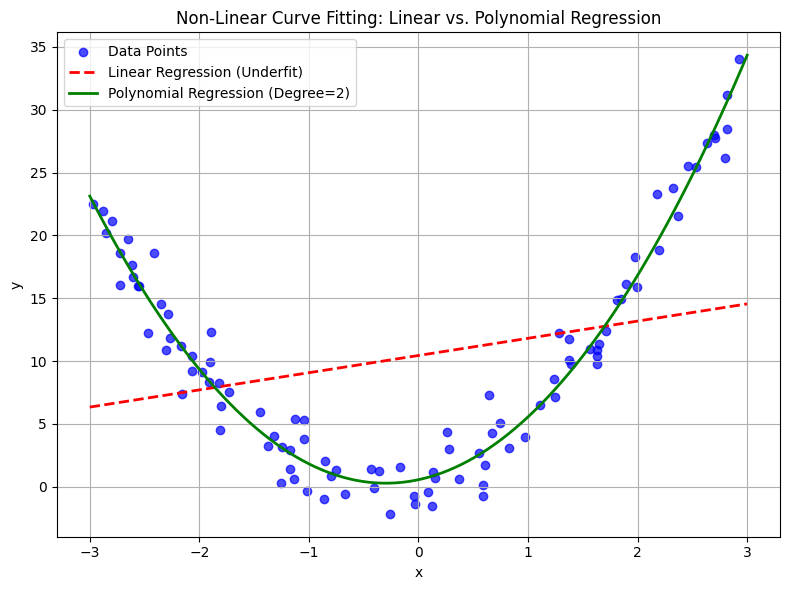

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Generate synthetic 2D data
np.random.seed(42)
x = np.random.uniform(-3, 3, 100).reshape(-1, 1)
noise = np.random.normal(0, 2, 100).reshape(-1, 1)
y = 3 * (x ** 2) + 2 * x + 1 + noise

# Save dataset to Poly_base.csv
df = pd.DataFrame({'x': x.flatten(), 'y': y.flatten()})
df.to_csv('Poly_base.csv', index=False)

# Generate sorted x values for smooth curve plotting
x_plot = np.linspace(-3, 3, 100).reshape(-1, 1)

# Fit standard Linear Regression model (Underfits)
lr = LinearRegression()
lr.fit(x, y)
y_pred_lr = lr.predict(x_plot)

# Transform input x using PolynomialFeatures (degree=2)
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)
x_plot_poly = poly.transform(x_plot)

# Fit Linear Regression model to the polynomial features
lr_poly = LinearRegression()
lr_poly.fit(x_poly, y)
y_pred_poly = lr_poly.predict(x_plot_poly)

# Plot the results
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, color='blue', alpha=0.7, label='Data Points')
ax.plot(x_plot, y_pred_lr, color='red', linestyle='--', linewidth=2, label='Linear Regression (Underfit)')
ax.plot(x_plot, y_pred_poly, color='green', linewidth=2, label='Polynomial Regression (Degree=2)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Non-Linear Curve Fitting: Linear vs. Polynomial Regression')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

**Visualizing the Bias-Variance Tradeoff**  
- Dataset: Complex_Non_linear_dataset.csv  
- The Task: Take a complex, non-linear 1D da taset.  
- Objectives:  
- Fit polynomial regression models of varying degrees (e.g., 1, 2, 5, 10, and 20).  
- For each degree, calculate both the training error and testing error.  
- Plot the degrees on the x-axis and the errors on the y-axis. Identify the point where the model stops learning the underlying pattern and starts memorizing the noise (overfitting).  

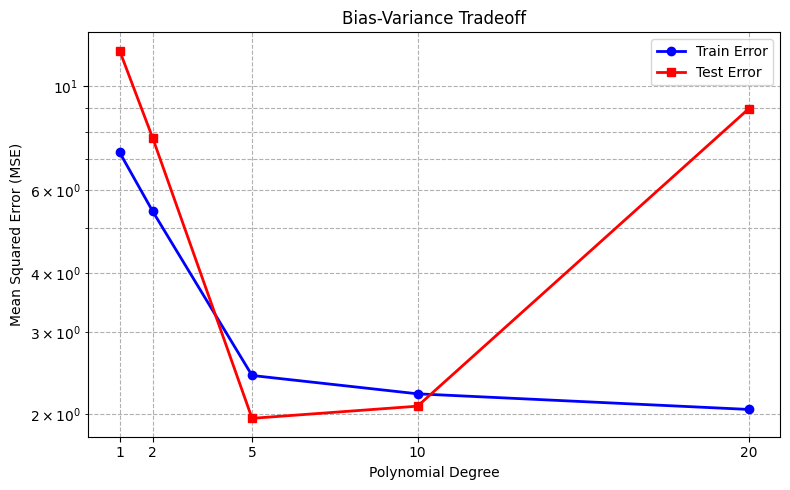

In [6]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Generate complex, non-linear 1D dataset
np.random.seed(42)
X = np.random.uniform(-3, 3, 150).reshape(-1, 1)
y = np.sin(X).flatten() * 5 + 0.5 * (X.flatten()**2) + np.random.normal(0, 1.5, 150)

# Save dataset
df = pd.DataFrame({'X': X.flatten(), 'y': y})
df.to_csv('Complex_Non_linear_dataset.csv', index=False)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees = [1, 2, 5, 10, 20]
train_errors = []
test_errors = []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test, model.predict(X_test_poly)))

# Plot Bias-Variance Tradeoff
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees, train_errors, label='Train Error', marker='o', color='blue', linewidth=2)
ax.plot(degrees, test_errors, label='Test Error', marker='s', color='red', linewidth=2)
ax.set_xlabel('Polynomial Degree')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Bias-Variance Tradeoff')
ax.set_xticks(degrees)
ax.set_yscale('log')
ax.legend()
ax.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()